## 0. Notebook Objective, Provenance & Scope
Audit and exploratory data analysis of the Z-Alizadeh Sani cardiovascular dataset for Track A. Establishes the data foundation, audits for target leakage, verifies schema integrity, and maps feature distributions without training models.

In [1]:
# Dataset Provenance & Scope Verification
dataset_provenance = {
    'Dataset Name': 'Extension of Z-Alizadeh Sani Dataset',
    'Source': 'UCI Machine Learning Repository / Kaggle',
    'Cohort Size': '303 patient records',
    'Raw Columns': '59 features and diagnostic outcomes',
    'Prediction Targets': 'Cath (Overall CAD), LAD stenosis, LCX stenosis, RCA stenosis',
    'Primary Task': 'Multi-target cardiovascular risk & vessel-specific stenosis prediction'
}
for k, v in dataset_provenance.items():
    print(f"{k:20s}: {v}")

Dataset Name        : Extension of Z-Alizadeh Sani Dataset
Source              : UCI Machine Learning Repository / Kaggle
Cohort Size         : 303 patient records
Raw Columns         : 59 features and diagnostic outcomes
Prediction Targets  : Cath (Overall CAD), LAD stenosis, LCX stenosis, RCA stenosis
Primary Task        : Multi-target cardiovascular risk & vessel-specific stenosis prediction


## 1. Environment & Reproducibility

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Dataset Loading

In [3]:
DATA_PATH = Path('extention of Z-Alizadeh sani dataset.xlsx')
df_raw = pd.read_excel(DATA_PATH)
df = df_raw.copy()
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

Loaded dataset: 303 rows, 59 columns


## 3. Dataset Identity & Schema Audit

In [4]:
schema_df = pd.DataFrame({
    'Column': df.columns,
    'Dtype': [str(df[col].dtype) for col in df.columns],
    'Non-Null Count': [df[col].notna().sum() for col in df.columns],
    'Missing Count': [df[col].isna().sum() for col in df.columns],
    'Missing %': [(df[col].isna().mean() * 100).round(2) for col in df.columns],
    'N_Unique': [df[col].nunique(dropna=False) for col in df.columns],
    'Sample Values': [str(df[col].unique()[:3].tolist()) for col in df.columns]
})
schema_df.index = range(1, len(schema_df) + 1)
display(schema_df)

,Column,Dtype,Non-Null Count,Missing Count,Missing %,N_Unique,Sample Values
1,Age,int64,303,0,0.0,46,"[53, 67, 54]"
2,Weight,int64,303,0,0.0,54,"[90, 70, 54]"
3,Length,int64,303,0,0.0,44,"[175, 157, 164]"
4,Sex,object,303,0,0.0,2,"['Male', 'Fmale']"
5,BMI,float64,303,0,0.0,263,"[29.387755102040817, 28.398718000730252, 20.07..."
6,DM,int64,303,0,0.0,2,"[0, 1]"
7,HTN,int64,303,0,0.0,2,"[1, 0]"
8,Current Smoker,int64,303,0,0.0,2,"[1, 0]"
9,EX-Smoker,int64,303,0,0.0,2,"[0, 1]"
10,FH,int64,303,0,0.0,2,"[0, 1]"


## 4. Target Definition & Raw Label Encoding Verification
Define the four primary prediction tasks as prescribed by Track A: overall CAD (`Cath`) and vessel stenosis (`LAD`, `LCX`, `RCA`), and verify raw labels for deterministic encoding in Notebook 2.

In [5]:
TARGETS = {
    'overall_cad': 'Cath',
    'lad_stenosis': 'LAD',
    'lcx_stenosis': 'LCX',
    'rca_stenosis': 'RCA'
}

TARGET_COLUMNS = list(TARGETS.values())
FEATURE_COLUMNS = [col for col in df.columns if col not in TARGET_COLUMNS]

print(f"Target count:  {len(TARGET_COLUMNS)} -> {TARGET_COLUMNS}")
print(f"Feature count: {len(FEATURE_COLUMNS)}")
assert len(set(TARGET_COLUMNS) & set(FEATURE_COLUMNS)) == 0

# Verify raw labels and define deterministic encoding contract for Notebook 2
target_label_contract = {}
for key, col in TARGETS.items():
    u_vals = df[col].unique().tolist()
    pos_val = 'CAD' if col == 'Cath' else 'Stenotic'
    neg_val = 'Normal'
    target_label_contract[col] = {
        'Task': key,
        'Raw Values': u_vals,
        'Positive (1)': pos_val,
        'Negative (0)': neg_val
    }
display(pd.DataFrame(target_label_contract).T)

Target count:  4 -> ['Cath', 'LAD', 'LCX', 'RCA']
Feature count: 55


,Task,Raw Values,Positive (1),Negative (0)
Cath,overall_cad,"[CAD, Normal]",CAD,Normal
LAD,lad_stenosis,"[Stenotic, Normal]",Stenotic,Normal
LCX,lcx_stenosis,"[Normal, Stenotic]",Stenotic,Normal
RCA,rca_stenosis,"[Stenotic, Normal]",Stenotic,Normal


## 5. Leakage & Prediction-Time Availability Audit
Verify that target variables, angiography outcomes, and post-diagnostic proxies are segregated from candidate model features. A strong association with a target does not constitute target leakage; features are excluded only when they directly encode or reveal outcome information unavailable at prediction time.

In [6]:
leakage_keywords = ['cad', 'cath', 'lad', 'lcx', 'rca', 'stenosis', 'angiograph']
flagged_features = [col for col in FEATURE_COLUMNS if any(k in col.lower() for k in leakage_keywords)]
print(f"Features matching post-diagnostic keywords: {flagged_features}")

# Prediction-Time Clinical Availability Audit
availability_audit = []
for col in df.columns:
    if col in TARGET_COLUMNS:
        avail = 'No'
        reason = 'Diagnostic ground truth target; prohibited from model inputs'
    elif col in ['Age', 'Sex', 'Weight', 'Length', 'BMI']:
        avail = 'Yes'
        reason = 'Patient demographics & baseline anthropometrics'
    elif col in ['DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Obesity', 'CRF', 'CVA', 'Airway disease', 'Thyroid Disease', 'CHF', 'DLP']:
        avail = 'Yes'
        reason = 'Medical history and chronic comorbidities'
    elif col in ['BP', 'PR', 'Edema', 'Weak Peripheral Pulse', 'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Typical Chest Pain', 'Dyspnea', 'Function Class', 'Atypical', 'Nonanginal', 'Exertional CP', 'LowTH Ang']:
        avail = 'Yes'
        reason = 'Physical examination & presenting symptoms'
    elif col in ['Q Wave', 'St Elevation', 'St Depression', 'Tinversion', 'LVH', 'Poor R Progression', 'BBB']:
        avail = 'Yes'
        reason = 'Non-invasive standard 12-lead ECG findings'
    elif col in ['FBS', 'CR', 'TG', 'LDL', 'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT']:
        avail = 'Yes'
        reason = 'Routine admission venous blood / lab panel'
    elif col in ['EF-TTE', 'Region RWMA', 'VHD']:
        avail = 'Yes'
        reason = 'Non-invasive echocardiographic exam; RWMA indicates regional wall motion, not a 3D lesion map'
    else:
        avail = 'Investigate'
        reason = 'Unclassified'
    
    availability_audit.append({
        'Feature': col,
        'Prediction-Time Available': avail,
        'Clinical Source & Rationale': reason
    })

avail_df = pd.DataFrame(availability_audit)
display(avail_df.head(15))
print(f"Total Prediction-Time Available Candidate Features: {(avail_df['Prediction-Time Available'] == 'Yes').sum()}")
print(f"Excluded Outcome Variables: {(avail_df['Prediction-Time Available'] == 'No').sum()}")

Features matching post-diagnostic keywords: []


,Feature,Prediction-Time Available,Clinical Source & Rationale
0,Age,Yes,Patient demographics & baseline anthropometrics
1,Weight,Yes,Patient demographics & baseline anthropometrics
2,Length,Yes,Patient demographics & baseline anthropometrics
3,Sex,Yes,Patient demographics & baseline anthropometrics
4,BMI,Yes,Patient demographics & baseline anthropometrics
5,DM,Yes,Medical history and chronic comorbidities
6,HTN,Yes,Medical history and chronic comorbidities
7,Current Smoker,Yes,Medical history and chronic comorbidities
8,EX-Smoker,Yes,Medical history and chronic comorbidities
9,FH,Yes,Medical history and chronic comorbidities


Total Prediction-Time Available Candidate Features: 55
Excluded Outcome Variables: 4


## 6. Data Quality Audit
Check for constant features, whitespace anomalies, duplicate rows, and memory usage. Identified candidate exclusions will be formally executed in Notebook 2.

In [7]:
# Constant or near-constant candidate features
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"Constant columns (zero variance): {constant_cols}")
for col in constant_cols:
    print(f"  {col}: {df[col].value_counts().to_dict()} -> Candidate for exclusion in Notebook 2")

# Check exact duplicate rows
n_dups = df.duplicated().sum()
n_feature_dups = df[FEATURE_COLUMNS].duplicated().sum()
print(f"Exact full duplicate rows: {n_dups}")
print(f"Feature-only duplicate rows: {n_feature_dups}")

# Audit for conflicting duplicate profiles (identical features but divergent target labels)
conflicting_dups = 0
if n_feature_dups > 0:
    for _, group in df.groupby(FEATURE_COLUMNS):
        if len(group) > 1 and group[TARGET_COLUMNS].nunique().max() > 1:
            conflicting_dups += 1
print(f"Conflicting duplicate patient profiles (identical features, different targets): {conflicting_dups}")

# Check object column unique values for whitespace or typo irregularities
str_cols = df.select_dtypes(include='object').columns.tolist()
typo_audit = {}
for col in str_cols:
    u = df[col].dropna().unique().tolist()
    typo_audit[col] = u
display(pd.Series(typo_audit, name='Unique Object Values'))

Constant columns (zero variance): ['Exertional CP']
  Exertional CP: {'N': 303} -> Candidate for exclusion in Notebook 2
Exact full duplicate rows: 0
Feature-only duplicate rows: 0
Conflicting duplicate patient profiles (identical features, different targets): 0


Sex                                    [Male, Fmale]
Obesity                                       [Y, N]
CRF                                           [N, Y]
CVA                                           [N, Y]
Airway disease                                [N, Y]
Thyroid Disease                               [N, Y]
CHF                                           [N, Y]
DLP                                           [Y, N]
Weak Peripheral Pulse                         [N, Y]
Lung rales                                    [N, Y]
Systolic Murmur                               [N, Y]
Diastolic Murmur                              [N, Y]
Dyspnea                                       [N, Y]
Atypical                                      [N, Y]
Nonanginal                                    [N, Y]
Exertional CP                                    [N]
LowTH Ang                                     [N, Y]
LVH                                           [N, Y]
Poor R Progression                            

## 7. Missing-Value Analysis

In [8]:
missing_summary = df.isna().sum()
total_missing = missing_summary.sum()
print(f"Total missing values across entire dataset: {total_missing}")

missing_by_col = missing_summary[missing_summary > 0]
if len(missing_by_col) == 0:
    print("Dataset contains zero missing entries across all 303 rows and 59 columns. No training imputation required for current cohort.")
else:
    display(missing_by_col)

Total missing values across entire dataset: 0
Dataset contains zero missing entries across all 303 rows and 59 columns. No training imputation required for current cohort.


## 8. Feature-Type Classification (Domain & Statistical Properties)
Partition candidate features using data type, unique values, and clinical domain semantics rather than naive unique counts alone.

In [9]:
# Classification using Dtype + Cardinality + Clinical Semantics
binary_cols = [
    'DM', 'HTN', 'Current Smoker', 'EX-Smoker', 'FH', 'Obesity', 'CRF', 'CVA', 
    'Airway disease', 'Thyroid Disease', 'CHF', 'DLP', 'Edema', 'Weak Peripheral Pulse', 
    'Lung rales', 'Systolic Murmur', 'Diastolic Murmur', 'Typical Chest Pain', 'Dyspnea', 
    'Atypical', 'Nonanginal', 'Exertional CP', 'LowTH Ang', 'Q Wave', 'St Elevation', 
    'St Depression', 'Tinversion', 'LVH', 'Poor R Progression', 'Sex'
]

nominal_multiclass_cols = ['BBB']
ordinal_cat_cols = ['VHD']
discrete_ordinal_num_cols = ['Function Class', 'Region RWMA']
continuous_num_cols = [
    'Age', 'Weight', 'Length', 'BMI', 'BP', 'PR', 'FBS', 'CR', 'TG', 'LDL', 
    'HDL', 'BUN', 'ESR', 'HB', 'K', 'Na', 'WBC', 'Lymph', 'Neut', 'PLT', 'EF-TTE'
]

feature_type_audit = pd.DataFrame([
    {'Category': 'Binary Categorical', 'Count': len(binary_cols), 'Features': ', '.join(binary_cols[:6]) + '...'},
    {'Category': 'Nominal Categorical', 'Count': len(nominal_multiclass_cols), 'Features': ', '.join(nominal_multiclass_cols)},
    {'Category': 'Ordinal Categorical', 'Count': len(ordinal_cat_cols), 'Features': ', '.join(ordinal_cat_cols)},
    {'Category': 'Discrete/Ordinal Numerical', 'Count': len(discrete_ordinal_num_cols), 'Features': ', '.join(discrete_ordinal_num_cols)},
    {'Category': 'Continuous Numerical', 'Count': len(continuous_num_cols), 'Features': ', '.join(continuous_num_cols[:6]) + '...'}
])
display(feature_type_audit)

,Category,Count,Features
0,Binary Categorical,30,"DM, HTN, Current Smoker, EX-Smoker, FH, Obesit..."
1,Nominal Categorical,1,BBB
2,Ordinal Categorical,1,VHD
3,Discrete/Ordinal Numerical,2,"Function Class, Region RWMA"
4,Continuous Numerical,21,"Age, Weight, Length, BMI, BP, PR..."


## 9. Target Distribution Analysis
Quantify class balance across all four target variables.

,Task,Column,Positive Class,N Pos,Pos %,N Neg,Neg %,Imbalance Ratio
0,overall_cad,Cath,CAD,216,71.29,87,28.71,2.48
1,lad_stenosis,LAD,Stenotic,177,58.42,126,41.58,1.40
2,lcx_stenosis,LCX,Stenotic,119,39.27,184,60.73,1.55
3,rca_stenosis,RCA,Stenotic,114,37.62,189,62.38,1.66


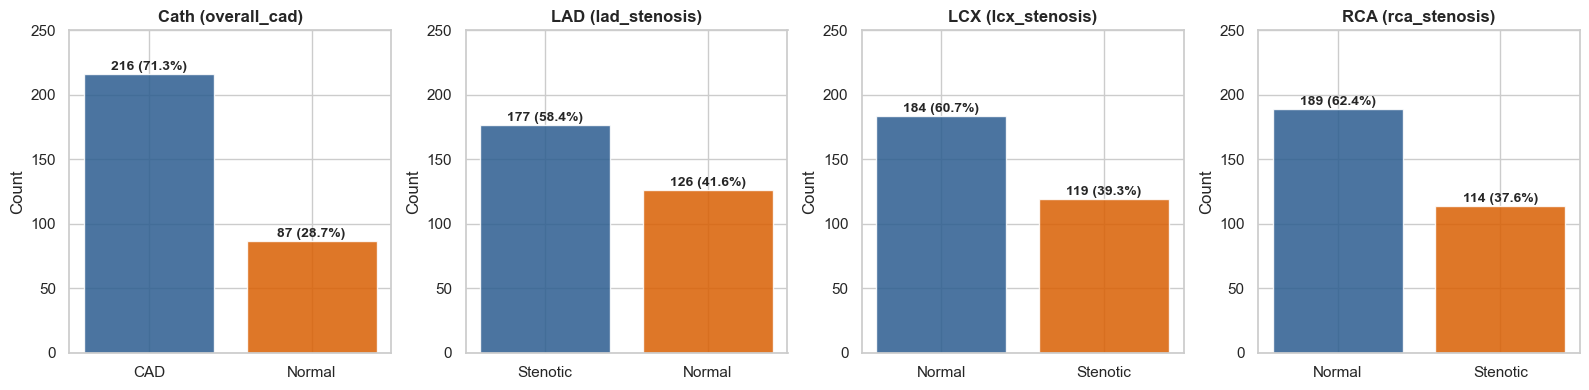

In [10]:
target_dist = []
for key, col in TARGETS.items():
    vc = df[col].value_counts()
    vp = (df[col].value_counts(normalize=True) * 100).round(2)
    pos_label = 'CAD' if col == 'Cath' else 'Stenotic'
    neg_label = 'Normal'
    n_pos = vc.get(pos_label, 0)
    n_neg = vc.get(neg_label, 0)
    pct_pos = vp.get(pos_label, 0.0)
    pct_neg = vp.get(neg_label, 0.0)
    target_dist.append({
        'Task': key,
        'Column': col,
        'Positive Class': pos_label,
        'N Pos': n_pos,
        'Pos %': pct_pos,
        'N Neg': n_neg,
        'Neg %': pct_neg,
        'Imbalance Ratio': round(max(n_pos, n_neg) / min(n_pos, n_neg), 2)
    })

target_dist_df = pd.DataFrame(target_dist)
display(target_dist_df)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (key, col) in enumerate(TARGETS.items()):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=['#2b5c8f', '#d95f02'], alpha=0.85)
    axes[i].set_title(f"{col} ({key})", fontsize=12, fontweight='bold')
    axes[i].set_ylabel("Count")
    for j, val in enumerate(counts.values):
        axes[i].text(j, val + 3, f"{val} ({val/len(df):.1%})", ha='center', fontweight='bold')
    axes[i].set_ylim(0, 250)
plt.tight_layout()
plt.show()

## 10. Numerical Feature EDA
Parametric summaries, skewness, and distribution characteristics across continuous and discrete features.

,Mean,Std,Median,IQR,Min,Max,Skew
Age,58.90,10.39,58.00,15.0,30.00,86.0,0.13
Weight,73.83,11.99,74.00,16.0,48.00,120.0,0.42
Length,164.72,9.33,165.00,13.0,140.00,188.0,-0.03
BMI,27.25,4.10,26.78,4.9,18.12,40.9,0.43
BP,129.55,18.94,130.00,20.0,90.00,190.0,0.57
PR,75.14,8.91,70.00,10.0,50.00,110.0,1.08
FBS,119.18,52.08,98.00,41.5,62.00,400.0,2.28
CR,1.06,0.26,1.00,0.3,0.50,2.2,0.95
TG,150.34,97.96,122.00,87.0,37.00,1050.0,3.78
LDL,104.64,35.40,100.00,42.0,18.00,232.0,0.57


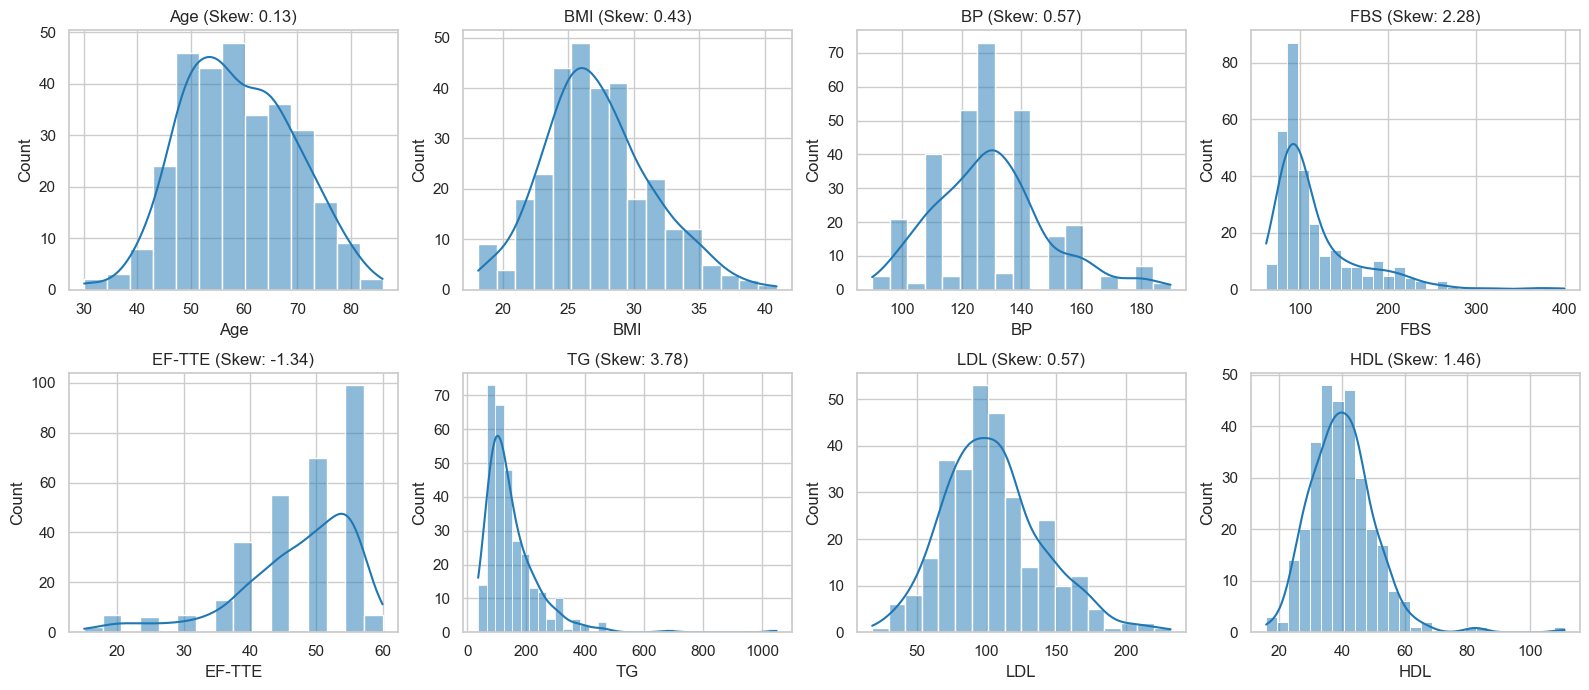

In [11]:
all_num_cols = continuous_num_cols + discrete_ordinal_num_cols
num_stats = pd.DataFrame({
    'Mean': df[all_num_cols].mean().round(2),
    'Std': df[all_num_cols].std().round(2),
    'Median': df[all_num_cols].median().round(2),
    'IQR': (df[all_num_cols].quantile(0.75) - df[all_num_cols].quantile(0.25)).round(2),
    'Min': df[all_num_cols].min().round(2),
    'Max': df[all_num_cols].max().round(2),
    'Skew': df[all_num_cols].skew().round(2)
})
display(num_stats)

key_num_plots = ['Age', 'BMI', 'BP', 'FBS', 'EF-TTE', 'TG', 'LDL', 'HDL']
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(key_num_plots):
    sns.histplot(df[col], kde=True, ax=axes[i], color='#1f77b4')
    axes[i].set_title(f"{col} (Skew: {df[col].skew():.2f})")
plt.tight_layout()
plt.show()

## 11. Categorical Feature EDA
Inspect distributions and frequency of binary indicators and categorical descriptors.

In [12]:
cat_summary = []
for col in binary_cols + nominal_multiclass_cols + ordinal_cat_cols:
    val_counts = df[col].value_counts().to_dict()
    dominant_val = list(val_counts.keys())[0]
    dominant_pct = round(list(val_counts.values())[0] / len(df) * 100, 2)
    cat_summary.append({
        'Feature': col,
        'Type': 'Binary' if col in binary_cols else ('Ordinal' if col in ordinal_cat_cols else 'Nominal'),
        'Categories': list(val_counts.keys()),
        'Dominant Category': dominant_val,
        'Dominant %': dominant_pct
    })
cat_summary_df = pd.DataFrame(cat_summary)
display(cat_summary_df)

,Feature,Type,Categories,Dominant Category,Dominant %
0,DM,Binary,"[0, 1]",0,70.30
1,HTN,Binary,"[1, 0]",1,59.08
2,Current Smoker,Binary,"[0, 1]",0,79.21
3,EX-Smoker,Binary,"[0, 1]",0,96.70
4,FH,Binary,"[0, 1]",0,84.16
5,Obesity,Binary,"[Y, N]",Y,69.64
6,CRF,Binary,"[N, Y]",N,98.02
7,CVA,Binary,"[N, Y]",N,98.35
8,Airway disease,Binary,"[N, Y]",N,96.37
9,Thyroid Disease,Binary,"[N, Y]",N,97.69


## 12. Feature-Target Relationships
Compare distribution differences of key clinical predictors against CAD status.

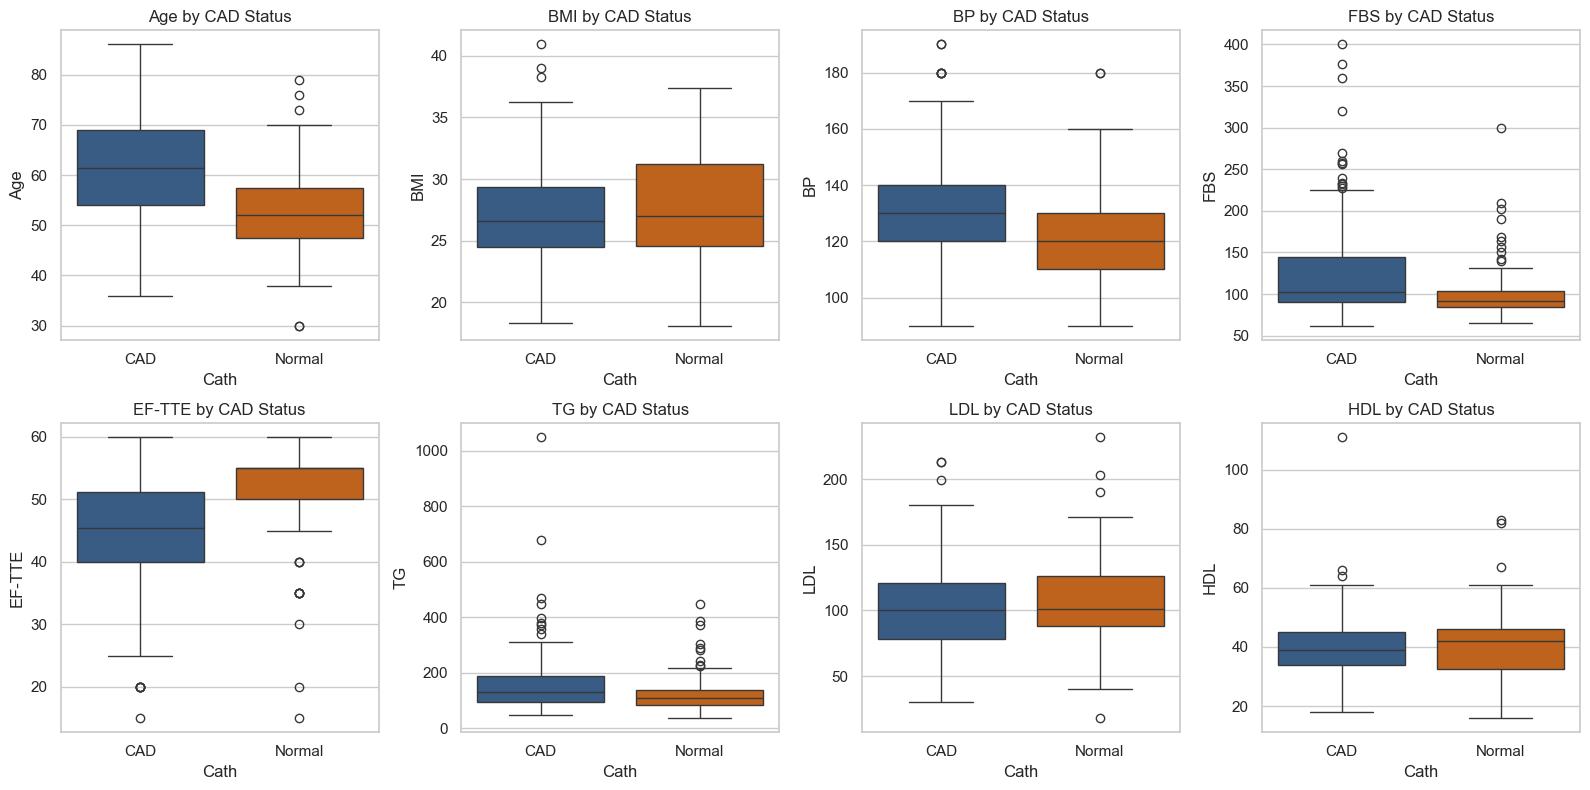

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(key_num_plots):
    sns.boxplot(x='Cath', y=col, data=df, ax=axes[i], palette=['#2b5c8f', '#d95f02'])
    axes[i].set_title(f"{col} by CAD Status")
plt.tight_layout()
plt.show()

## 13. Outlier & Clinical Plausibility Audit
Evaluate extreme physiological measurements against medical domain ranges.

In [14]:
plausibility_checks = {
    'Age': (df['Age'] < 18) | (df['Age'] > 100),
    'BP': (df['BP'] < 70) | (df['BP'] > 240),
    'PR': (df['PR'] < 40) | (df['PR'] > 200),
    'BMI': (df['BMI'] < 12) | (df['BMI'] > 60),
    'EF-TTE': (df['EF-TTE'] < 10) | (df['EF-TTE'] > 85),
    'FBS': (df['FBS'] < 40) | (df['FBS'] > 500),
    'K': (df['K'] < 2.0) | (df['K'] > 7.5),
    'Na': (df['Na'] < 110) | (df['Na'] > 165)
}

implausible_records = {k: v.sum() for k, v in plausibility_checks.items()}
display(pd.Series(implausible_records, name='Clinically Implausible Violations'))

# Statistical IQR outlier detection
outlier_counts = {}
for col in continuous_num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))).sum()
    if n_out > 0:
        outlier_counts[col] = n_out
display(pd.Series(outlier_counts, name='IQR Outlier Count (>1.5 IQR)'))

Age       0
BP        0
PR        0
BMI       0
EF-TTE    0
FBS       0
K         0
Na        0
Name: Clinically Implausible Violations, dtype: int64

Weight     3
BMI        6
BP         9
PR        13
FBS       30
CR         8
TG        16
LDL        6
HDL        6
BUN       17
ESR       13
HB         7
K          2
Na        15
WBC        9
Lymph      3
Neut       1
PLT       11
EF-TTE    15
Name: IQR Outlier Count (>1.5 IQR), dtype: int64

## 14. Duplicate and Near-Duplicate Audit
Check if identical clinical profiles exist across feature subsets.

In [15]:
vitals_demo = ['Age', 'Weight', 'Length', 'Sex', 'BMI', 'BP', 'PR']
dup_vitals = df[vitals_demo].duplicated(keep=False).sum()
print(f"Patients sharing identical demographics and vitals ({vitals_demo}): {dup_vitals}")

if dup_vitals > 0:
    display(df[df[vitals_demo].duplicated(keep=False)][vitals_demo + TARGET_COLUMNS].sort_values('Age'))

Patients sharing identical demographics and vitals (['Age', 'Weight', 'Length', 'Sex', 'BMI', 'BP', 'PR']): 0


## 15. Correlation & Redundancy Analysis
Detect collinearity among continuous lab and physiological metrics.

,Feature 1,Feature 2,Correlation
2,Lymph,Neut,-0.923
0,Weight,BMI,0.725
1,CR,BUN,0.512


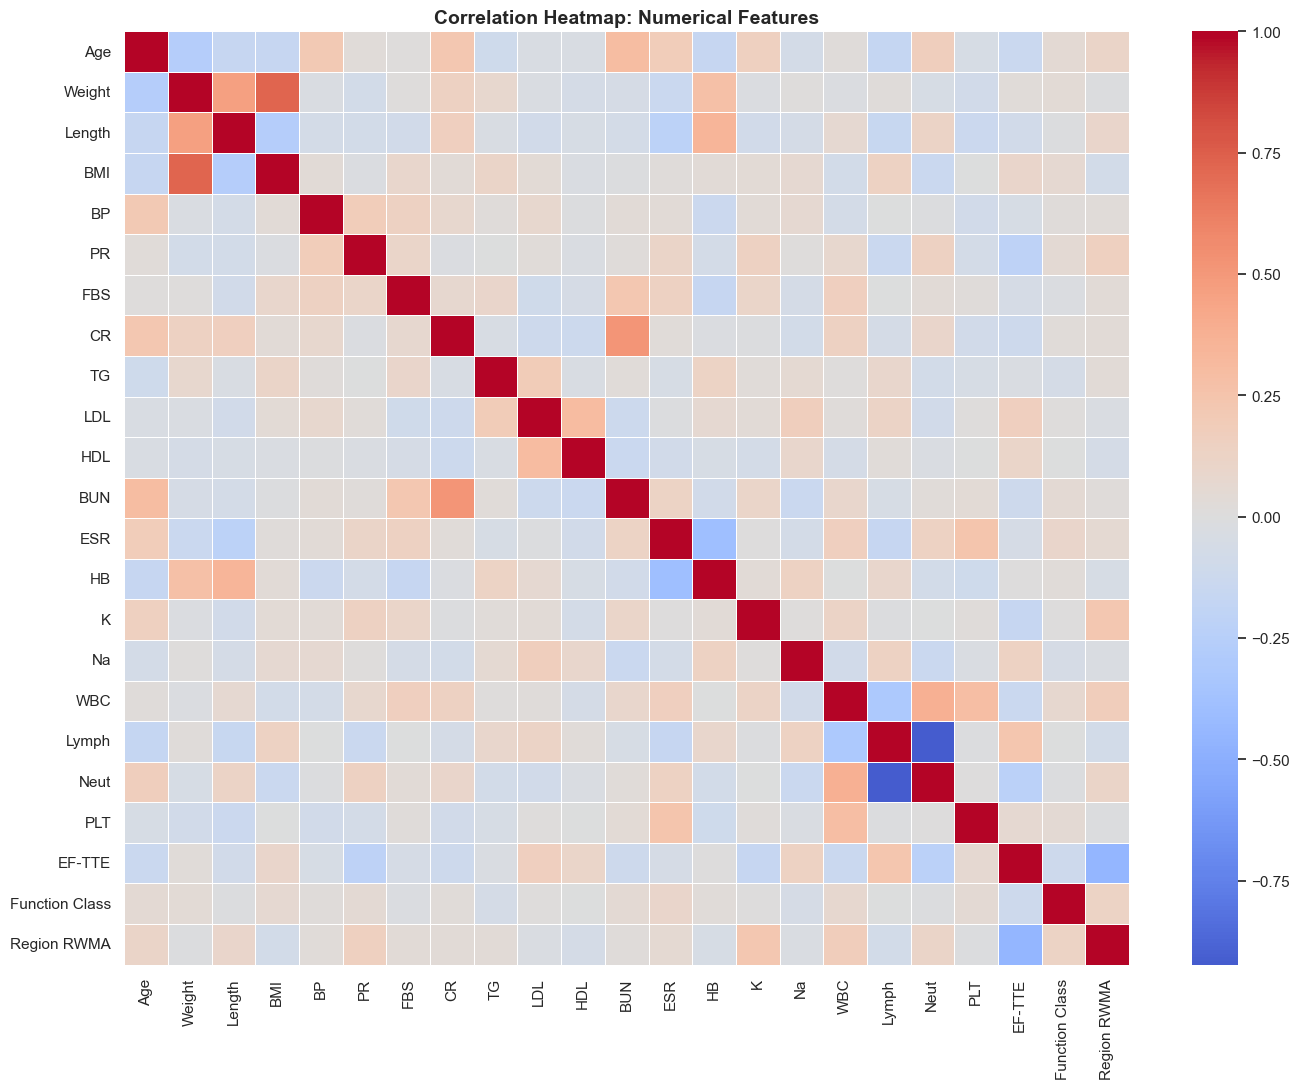

In [16]:
corr_matrix = df[all_num_cols].corr()

# Extract top correlated pairs (|r| > 0.5)
pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= 0.5:
            pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(r, 3)
            })
corr_pairs_df = pd.DataFrame(pairs).sort_values('Correlation', key=abs, ascending=False)
display(corr_pairs_df)

plt.figure(figsize=(14, 11))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False, linewidths=0.5)
plt.title("Correlation Heatmap: Numerical Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Cross-Target Relationship Analysis
Dataset consistency check: verify concordance between overall CAD status and individual artery stenosis (LAD, LCX, RCA). Every CAD-labelled patient has at least one stenotic vessel, and every patient with no stenotic vessel is labelled Normal. There is exactly one exception: one patient with a single stenotic vessel is labelled Normal in `Cath` (see the cross-tabulation below). The label is kept as recorded in the source dataset.

CAD (Cath),0,1
Stenotic Vessels (0-3),,
0,86,0
1,1,86
2,0,67
3,0,63


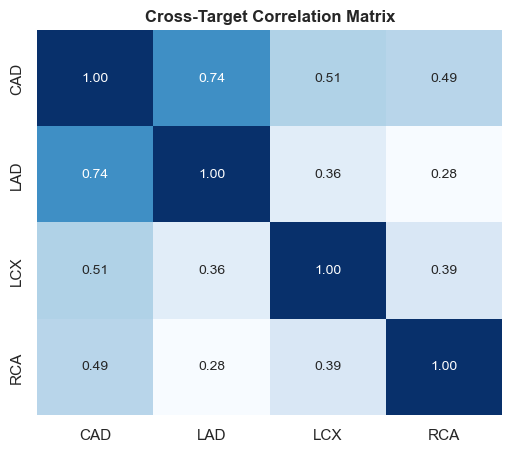

In [17]:
target_binary = pd.DataFrame({
    'CAD': (df['Cath'] == 'CAD').astype(int),
    'LAD': (df['LAD'] == 'Stenotic').astype(int),
    'LCX': (df['LCX'] == 'Stenotic').astype(int),
    'RCA': (df['RCA'] == 'Stenotic').astype(int)
})

# Cross-tabulation: Stenosis sum vs CAD
target_binary['Stenotic_Vessel_Count'] = target_binary[['LAD', 'LCX', 'RCA']].sum(axis=1)
vessel_vs_cad = pd.crosstab(target_binary['Stenotic_Vessel_Count'], target_binary['CAD'], 
                            rownames=['Stenotic Vessels (0-3)'], colnames=['CAD (Cath)'])
display(vessel_vs_cad)

# Co-occurrence correlation matrix
target_corr = target_binary[['CAD', 'LAD', 'LCX', 'RCA']].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(target_corr, annot=True, fmt='.2f', cmap='Blues', cbar=False)
plt.title("Cross-Target Correlation Matrix", fontsize=12, fontweight='bold')
plt.show()

## 17. Exploratory Feature Association with CAD Target
Exploratory statistical associations (point-biserial) for understanding signal strength. Feature-target associations and correlations identified in this notebook are exploratory only and will not be used to manually select or remove features before cross-validation.

In [18]:
target_num = target_binary['CAD']
assoc_records = []
for col in all_num_cols:
    r = np.corrcoef(df[col], target_num)[0, 1]
    assoc_records.append({'Feature': col, 'Correlation_with_CAD': round(r, 3)})

assoc_df = pd.DataFrame(assoc_records).sort_values('Correlation_with_CAD', key=abs, ascending=False)
display(assoc_df.head(15))

,Feature,Correlation_with_CAD
0,Age,0.357
22,Region RWMA,0.316
4,BP,0.238
20,EF-TTE,-0.234
6,FBS,0.206
14,K,0.181
12,ESR,0.178
5,PR,0.168
8,TG,0.141
17,Lymph,-0.127


## 18. Scope Boundaries: What Notebook 1 Does NOT Do
Explicit methodological boundaries to protect against data snooping, leakage, and premature model bias.

In [19]:
scope_boundaries = pd.DataFrame([
    {'Prohibited Action': 'Model Training', 'Rationale': 'No estimators (LogisticRegression, RF, XGB) fit here.'},
    {'Prohibited Action': 'Hyperparameter Tuning', 'Rationale': 'Reserved for Notebook 5 within stratified training folds.'},
    {'Prohibited Action': 'Feature Selection from EDA', 'Rationale': 'Selecting features via whole-dataset correlation introduces selection leakage.'},
    {'Prohibited Action': 'Target Exclusion as Input', 'Rationale': 'Cath, LAD, LCX, RCA strictly isolated; never enter feature matrices.'},
    {'Prohibited Action': 'Outlier Deletion', 'Rationale': 'Clinical observations represent genuine acute physiology; not corrupted entries.'},
    {'Prohibited Action': 'Premature SMOTE / Resampling', 'Rationale': 'Any oversampling must occur strictly within training folds in later notebooks.'}
])
display(scope_boundaries)

,Prohibited Action,Rationale
0,Model Training,"No estimators (LogisticRegression, RF, XGB) fi..."
1,Hyperparameter Tuning,Reserved for Notebook 5 within stratified trai...
2,Feature Selection from EDA,Selecting features via whole-dataset correlati...
3,Target Exclusion as Input,"Cath, LAD, LCX, RCA strictly isolated; never e..."
4,Outlier Deletion,Clinical observations represent genuine acute ...
5,Premature SMOTE / Resampling,Any oversampling must occur strictly within tr...


## 19. Data Cleaning & Modeling Handoff Decisions
Formal handoff contract transferring verified dataset constraints directly to Notebook 2.

In [20]:
handoff_decisions = pd.DataFrame([
    {'Finding': '0 missing values across 303 rows', 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'No training imputation required for current cohort.'},
    {'Finding': 'Exertional CP zero variance (all N)', 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'Exclude column during pipeline construction.'},
    {'Finding': 'Sex typographical error (Fmale)', 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'Normalize values to Female before one-hot/label encoding.'},
    {'Finding': 'BBB nominal multiclass (N, LBBB, RBBB)', 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'Candidate for One-Hot Encoding.'},
    {'Finding': 'VHD ordinal clinical category', 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'Encoding strategy (Ordinal vs One-Hot) to be evaluated.'},
    {'Finding': '0 exact or conflicting duplicates', 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'Retain all 303 patient records.'},
    {'Finding': 'No implausible physiological values', 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'Retain full clinical cohort without data discarding.'},
    {'Finding': f"High collinearity (Neut-Lymph r={corr_matrix.loc['Lymph', 'Neut']:.2f})", 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'Do not drop; tree models handle naturally; regularize linear baselines.'},
    {'Finding': 'Target hierarchy verified', 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'Exclude Cath, LAD, LCX, RCA from all input matrices.'},
    {'Finding': 'Cohort size N=303', 'Status': 'Confirmed', 'Handoff Action for Notebook 2': 'Recommended validation strategy: Repeated Stratified K-Fold CV.'}
])
display(handoff_decisions)

,Finding,Status,Handoff Action for Notebook 2
0,0 missing values across 303 rows,Confirmed,No training imputation required for current co...
1,Exertional CP zero variance (all N),Confirmed,Exclude column during pipeline construction.
2,Sex typographical error (Fmale),Confirmed,Normalize values to Female before one-hot/labe...
3,"BBB nominal multiclass (N, LBBB, RBBB)",Confirmed,Candidate for One-Hot Encoding.
4,VHD ordinal clinical category,Confirmed,Encoding strategy (Ordinal vs One-Hot) to be e...
5,0 exact or conflicting duplicates,Confirmed,Retain all 303 patient records.
6,No implausible physiological values,Confirmed,Retain full clinical cohort without data disca...
7,High collinearity (Neut-Lymph r=-0.92),Confirmed,Do not drop; tree models handle naturally; reg...
8,Target hierarchy verified,Confirmed,"Exclude Cath, LAD, LCX, RCA from all input mat..."
9,Cohort size N=303,Confirmed,Recommended validation strategy: Repeated Stra...


## 20. Final Feature / Target Specification
Locked specification defining exact targets, candidate input features, and formal data contract for Notebook 2.

In [21]:
final_spec = {
    'total_samples': len(df),
    'targets': TARGETS,
    'target_encoding_contract': {
        'Cath': {'CAD': 1, 'Normal': 0},
        'LAD': {'Stenotic': 1, 'Normal': 0},
        'LCX': {'Stenotic': 1, 'Normal': 0},
        'RCA': {'Stenotic': 1, 'Normal': 0}
    },
    'excluded_target_columns': TARGET_COLUMNS,
    'candidate_columns_to_exclude_in_nb2': ['Exertional CP'],
    'candidate_features_count': len(FEATURE_COLUMNS),
    'feature_classification': {
        'binary_categorical': binary_cols,
        'nominal_categorical': nominal_multiclass_cols,
        'ordinal_categorical': ordinal_cat_cols,
        'discrete_ordinal_numerical': discrete_ordinal_num_cols,
        'continuous_numerical': continuous_num_cols
    }
}

print(f"Audited Target Columns:              {list(final_spec['targets'].values())}")
print(f"Candidate Features for Notebook 2:   {final_spec['candidate_features_count']}")
print("Data audit & EDA complete. All methodological improvements verified and locked.")

Audited Target Columns:              ['Cath', 'LAD', 'LCX', 'RCA']
Candidate Features for Notebook 2:   55
Data audit & EDA complete. All methodological improvements verified and locked.
